In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import cv2

## Información del dataset

Decidir qué dimensiones utilizar en todas las imagenes, para luego poder jugar con paddings extras y así todo encaje como se desea

### Raw

#### Test & Train

In [2]:
data_path = Path("../data/raw/train")
imgs_path = list(data_path.rglob("*.jpg"))

data_path = Path("../data/raw/test")
imgs_path.extend(list(data_path.rglob("*.jpg")))

sizes = {"path": [], "width": [], "height": []}
for img_path in imgs_path:
    img = cv2.imread(str(img_path))
    sizes["path"].append(str(img_path))
    sizes["width"].append(img.shape[1])
    sizes["height"].append(img.shape[0])


In [3]:
df = pd.DataFrame(sizes)
df["ratio"] = df["width"] / df["height"]
df

,path,width,height,ratio
0,../data/raw/train/images/459_0.jpg,88,60,1.466667
1,../data/raw/train/images/195_9.jpg,90,60,1.500000
2,../data/raw/train/images/333_0.jpg,78,60,1.300000
3,../data/raw/train/images/95_1.jpg,228,64,3.562500
4,../data/raw/train/images/340_0.jpg,436,108,4.037037
...,...,...,...,...
1152,../data/raw/test/images/34_0.jpg,224,60,3.733333
1153,../data/raw/test/images/323_0.jpg,210,60,3.500000
1154,../data/raw/test/images/164_1.jpg,474,73,6.493151
1155,../data/raw/test/images/45_1.jpg,189,60,3.150000


In [4]:
df.describe()

,width,height,ratio
count,1157.000000,1157.000000,1157.000000
mean,202.987035,66.009507,3.097990
std,139.686267,20.938799,1.876551
min,26.000000,60.000000,0.433333
25%,105.000000,60.000000,1.616667
50%,177.000000,60.000000,2.850000
75%,255.000000,60.000000,3.969697
max,1490.000000,354.000000,13.066667


In [5]:
extremums = df[
    (df["height"] == df["height"].max()) |
    (df["width"] == df["width"].max()) |
    (df["width"] == df["width"].min())
]

first_subset = df[(df["height"] <= 200) & (df["width"] <= 600)]

display(extremums, first_subset)

,path,width,height,ratio
237,../data/raw/train/images/174_15.jpg,26,60,0.433333
261,../data/raw/train/images/209_0.jpg,895,354,2.528249
306,../data/raw/train/images/6_0.jpg,1490,251,5.936255


,path,width,height,ratio
0,../data/raw/train/images/459_0.jpg,88,60,1.466667
1,../data/raw/train/images/195_9.jpg,90,60,1.500000
2,../data/raw/train/images/333_0.jpg,78,60,1.300000
3,../data/raw/train/images/95_1.jpg,228,64,3.562500
4,../data/raw/train/images/340_0.jpg,436,108,4.037037
...,...,...,...,...
1152,../data/raw/test/images/34_0.jpg,224,60,3.733333
1153,../data/raw/test/images/323_0.jpg,210,60,3.500000
1154,../data/raw/test/images/164_1.jpg,474,73,6.493151
1155,../data/raw/test/images/45_1.jpg,189,60,3.150000


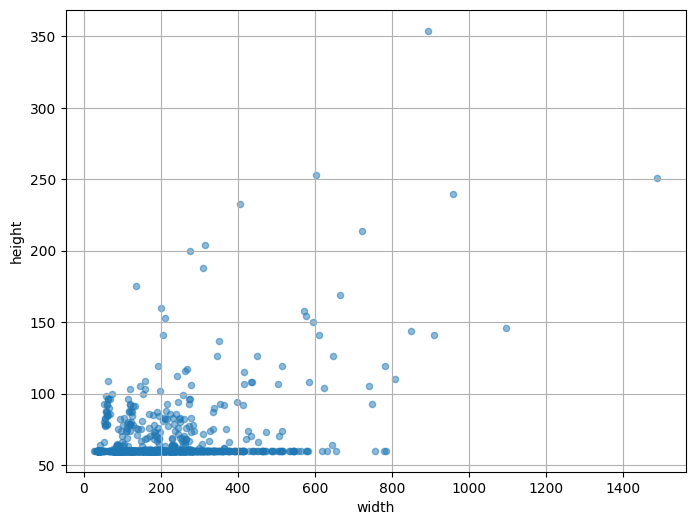

In [6]:
df.plot.scatter(x="width", y="height", alpha=0.5, figsize=(8, 6), grid=True)
plt.show()

#### Character

In [7]:
data_path = Path("../data/raw/character")
imgs_path = list(data_path.glob("*.jpg"))
sizes = {"path": [], "width": [], "height": []}
for img_path in imgs_path:
    img = cv2.imread(str(img_path))
    sizes["path"].append(str(img_path))
    sizes["width"].append(img.shape[1])
    sizes["height"].append(img.shape[0])

In [8]:
df = pd.DataFrame(sizes)
df["ratio"] = df["width"] / df["height"]
display(df, df.describe())

,path,width,height,ratio
0,../data/raw/character/449_0_1.jpg,104,177,0.587571
1,../data/raw/character/221_0_0.jpg,72,105,0.685714
2,../data/raw/character/205_0_4.jpg,92,134,0.686567
3,../data/raw/character/48_11_3.jpg,106,166,0.638554
4,../data/raw/character/496_0_5.jpg,66,96,0.687500
...,...,...,...,...
5135,../data/raw/character/131_0_10.jpg,40,61,0.655738
5136,../data/raw/character/432_0_5.jpg,53,88,0.602273
5137,../data/raw/character/257_0_6.jpg,40,67,0.597015
5138,../data/raw/character/271_0_1.jpg,102,155,0.658065


,width,height,ratio
count,5140.000000,5140.000000,5140.000000
mean,99.844553,155.538521,0.645129
std,65.276470,101.270583,0.056561
min,22.000000,38.000000,0.169014
25%,56.000000,87.000000,0.613835
50%,80.000000,127.500000,0.644068
75%,116.000000,180.000000,0.676923
max,470.000000,618.000000,1.338645


<Axes: ylabel='count'>

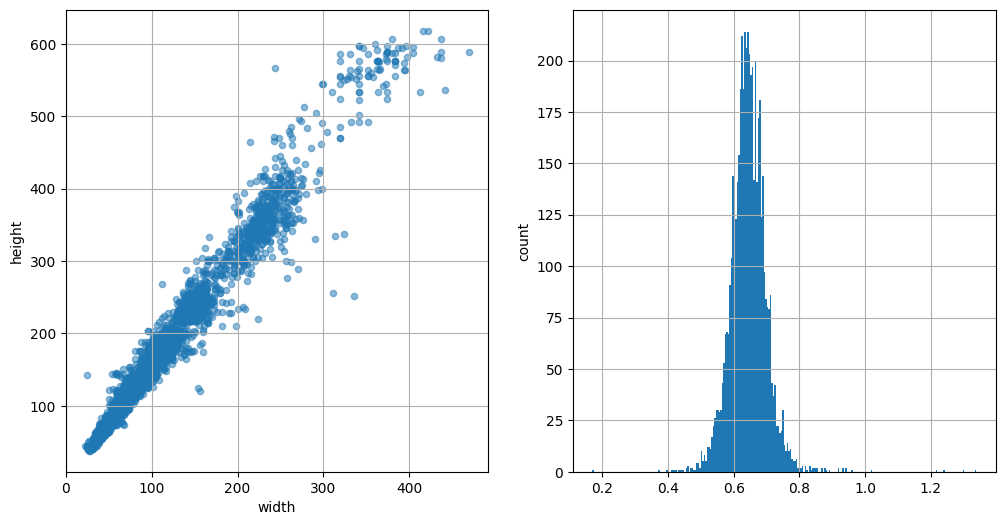

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
df.plot.scatter(x="width", y="height", alpha=0.5, grid=True, ax=axes[0])
df["ratio"].plot.hist(x="ratio", ylabel="count", bins=255, grid=True, ax=axes[1])

### Processed

#### Train & Test

In [10]:
data_path = Path("../data/raw/train")
imgs_path = list(data_path.rglob("*.jpg"))

data_path = Path("../data/raw/test")
imgs_path.extend(list(data_path.rglob("*.jpg")))

sizes = {"path": [], "width": [], "height": []}
for img_path in imgs_path:
    img = cv2.imread(str(img_path))
    sizes["path"].append(str(img_path))
    sizes["width"].append(img.shape[1])
    sizes["height"].append(img.shape[0])


In [11]:
df = pd.DataFrame(sizes)
df["ratio"] = df["width"] / df["height"]
df

,path,width,height,ratio
0,../data/raw/train/images/459_0.jpg,88,60,1.466667
1,../data/raw/train/images/195_9.jpg,90,60,1.500000
2,../data/raw/train/images/333_0.jpg,78,60,1.300000
3,../data/raw/train/images/95_1.jpg,228,64,3.562500
4,../data/raw/train/images/340_0.jpg,436,108,4.037037
...,...,...,...,...
1152,../data/raw/test/images/34_0.jpg,224,60,3.733333
1153,../data/raw/test/images/323_0.jpg,210,60,3.500000
1154,../data/raw/test/images/164_1.jpg,474,73,6.493151
1155,../data/raw/test/images/45_1.jpg,189,60,3.150000


In [12]:
df.describe()

,width,height,ratio
count,1157.000000,1157.000000,1157.000000
mean,202.987035,66.009507,3.097990
std,139.686267,20.938799,1.876551
min,26.000000,60.000000,0.433333
25%,105.000000,60.000000,1.616667
50%,177.000000,60.000000,2.850000
75%,255.000000,60.000000,3.969697
max,1490.000000,354.000000,13.066667


## Kaggle

Son todas imagenes de 28x28 en escala de grises

In [8]:
data_path = Path("../data/processed/kaggle")
imgs_path = list(data_path.rglob("*.jpg"))

sizes = {"path": [], "width": [], "height": []}
for img_path in imgs_path:
    img = cv2.imread(str(img_path))
    sizes["path"].append(str(img_path))
    sizes["width"].append(img.shape[1])
    sizes["height"].append(img.shape[0])

In [13]:
df = pd.DataFrame(sizes)
df["ratio"] = df["width"] / df["height"]
display(df, df.describe())

,path,width,height,ratio
0,../data/raw/train/images/459_0.jpg,88,60,1.466667
1,../data/raw/train/images/195_9.jpg,90,60,1.500000
2,../data/raw/train/images/333_0.jpg,78,60,1.300000
3,../data/raw/train/images/95_1.jpg,228,64,3.562500
4,../data/raw/train/images/340_0.jpg,436,108,4.037037
...,...,...,...,...
1152,../data/raw/test/images/34_0.jpg,224,60,3.733333
1153,../data/raw/test/images/323_0.jpg,210,60,3.500000
1154,../data/raw/test/images/164_1.jpg,474,73,6.493151
1155,../data/raw/test/images/45_1.jpg,189,60,3.150000


,width,height,ratio
count,1157.000000,1157.000000,1157.000000
mean,202.987035,66.009507,3.097990
std,139.686267,20.938799,1.876551
min,26.000000,60.000000,0.433333
25%,105.000000,60.000000,1.616667
50%,177.000000,60.000000,2.850000
75%,255.000000,60.000000,3.969697
max,1490.000000,354.000000,13.066667


### Yolo

In [21]:
import os
import sys

parent = os.path.abspath("..")
if parent not in sys.path:
    sys.path.append(parent)

from src.config import settings

In [22]:
data_path = Path("../data/processed/kaggle/yolo")
imgs_path = list(data_path.rglob("*.jpg"))

sizes = {"path": [], "stage": [], "label": []}
for img_path in imgs_path:
    filename = img_path.name
    sizes["path"].append(str(img_path))
    sizes["stage"].append(img_path.parents[1].name)
    sizes["label"].append(settings.get_class_name(filename))

In [31]:
df = pd.DataFrame(sizes)
display(
    df,
    df.groupby("stage").count(),
    df.groupby("label").count(),
)

,path,stage,label
0,../data/processed/kaggle/yolo/train/images/a1....,train,a
1,../data/processed/kaggle/yolo/train/images/k1....,train,k
2,../data/processed/kaggle/yolo/train/images/q1....,train,q
3,../data/processed/kaggle/yolo/train/images/m1....,train,m
4,../data/processed/kaggle/yolo/train/images/q1....,train,q
...,...,...,...
28075,../data/processed/kaggle/yolo/test/images/q1.J...,test,q
28076,../data/processed/kaggle/yolo/test/images/p1.J...,test,p
28077,../data/processed/kaggle/yolo/test/images/j1.J...,test,j
28078,../data/processed/kaggle/yolo/test/images/f1.J...,test,f


,path,label
stage,,
test,7020,7020
train,21060,21060


,path,stage
label,,
a,1080,1080
b,1080,1080
c,1080,1080
d,1080,1080
e,1080,1080
f,1080,1080
g,1080,1080
h,1080,1080
i,1080,1080
